# Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("All libraries imported successfully!")

All libraries imported successfully!


# Load and Inspect Dataset

In [ ]:
crop = pd.read_csv("Crop_recommendation.csv")
print("Dataset Loaded Successfully!\n")

# Basic Overview
print("Shape:", crop.shape)
print("\n Columns:", crop.columns.tolist())
print("\n Missing Values:\n", crop.isnull().sum())
print("\n Unique Crops:", crop['label'].nunique())

# Preview
crop.head()

Dataset Loaded Successfully!

Shape: (2200, 8)

 Columns: ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label']

 Missing Values:
 N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

 Unique Crops: 22


,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


# EDA

/tmp/ipython-input-2810592587.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=crop['label'], palette='tab20', order=crop['label'].value_counts().index)


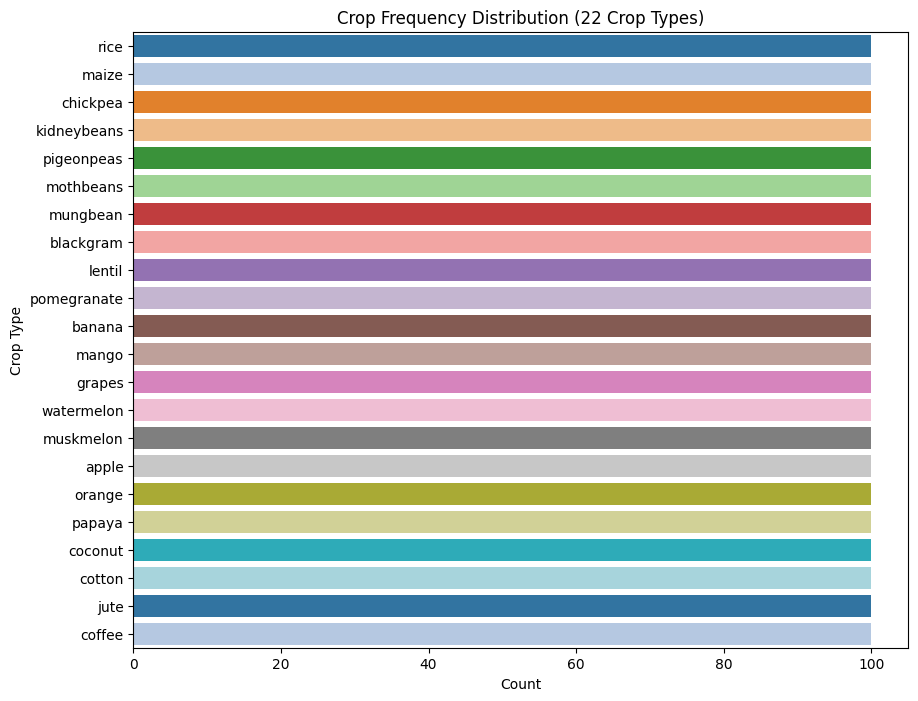

/tmp/ipython-input-2810592587.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=crop, x='label', y='N', palette='tab20')


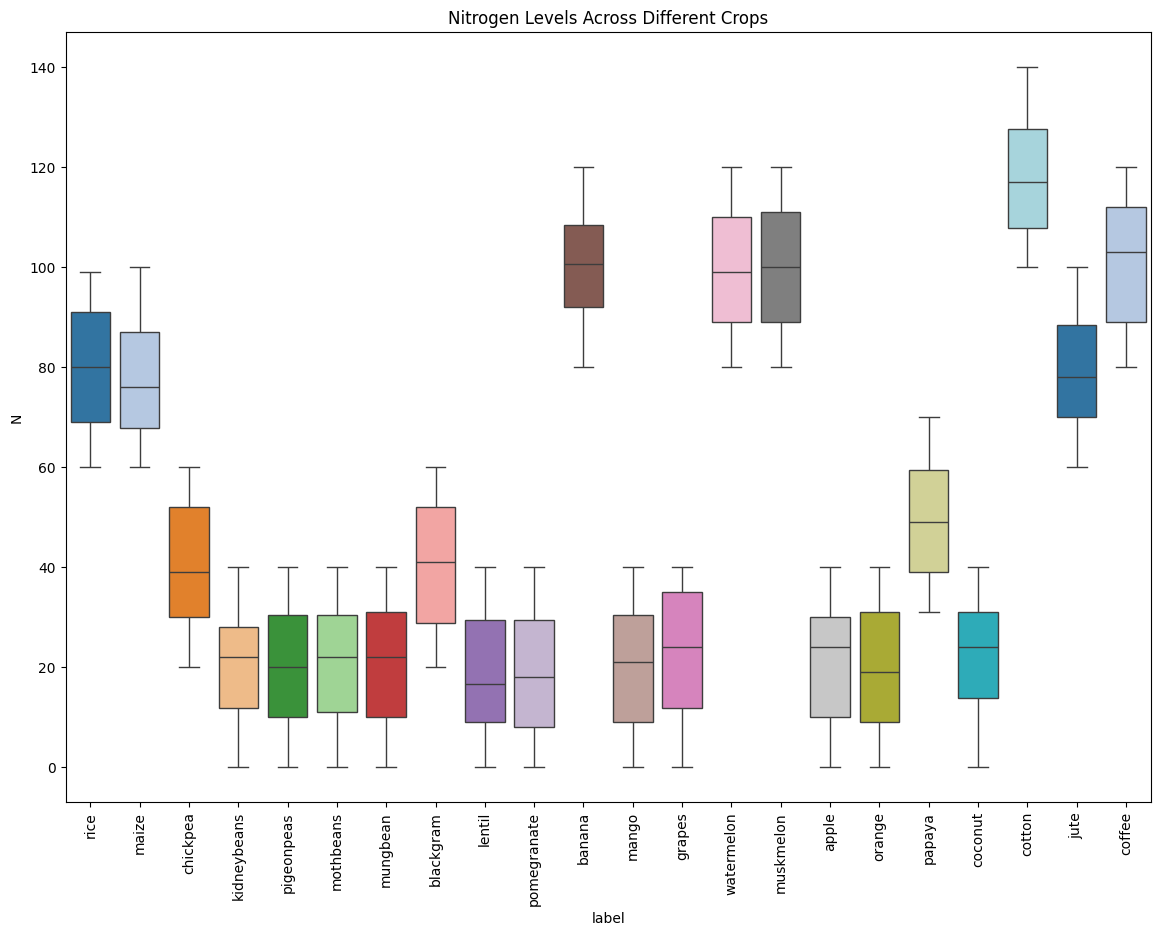

/tmp/ipython-input-2810592587.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=crop, x='label', y='P', palette='tab20')


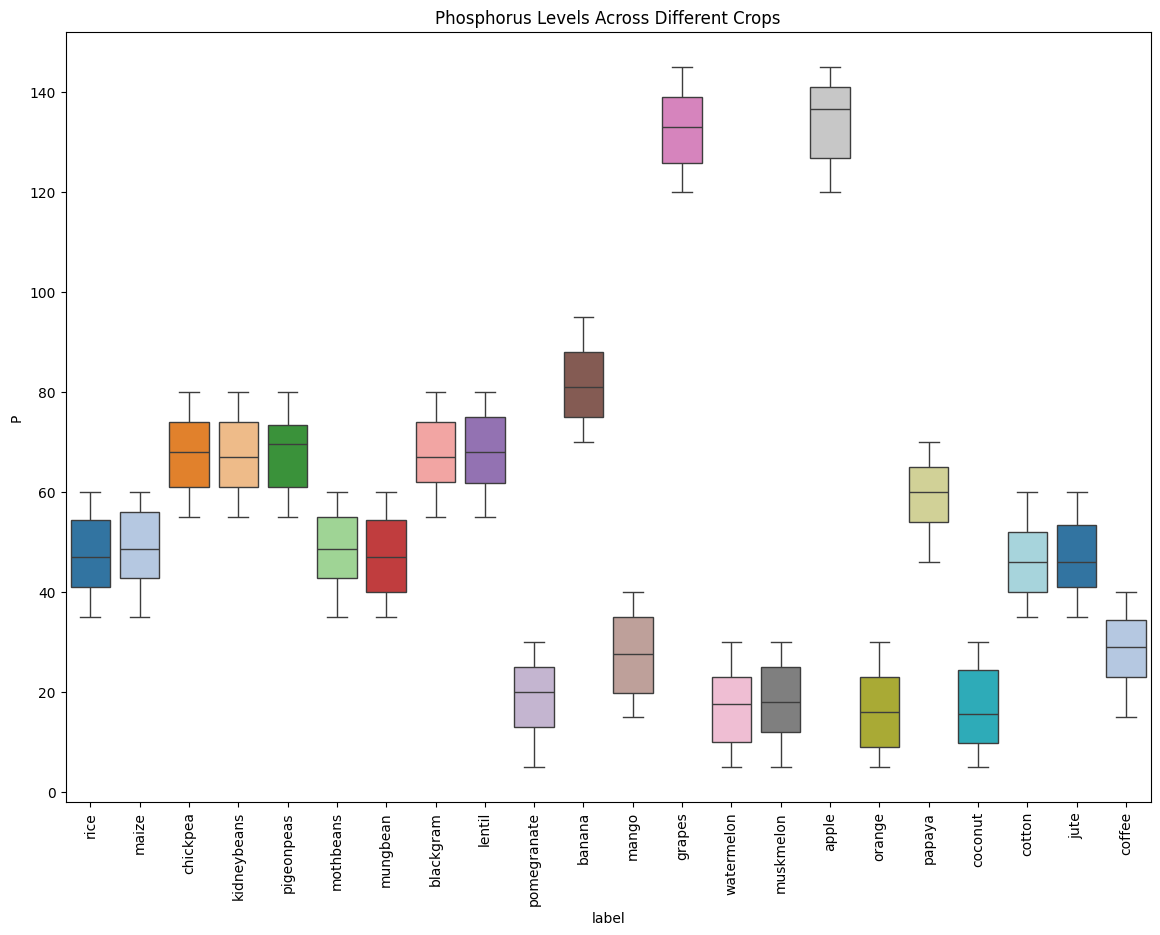

/tmp/ipython-input-2810592587.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=crop, x='label', y='K', palette='tab20')


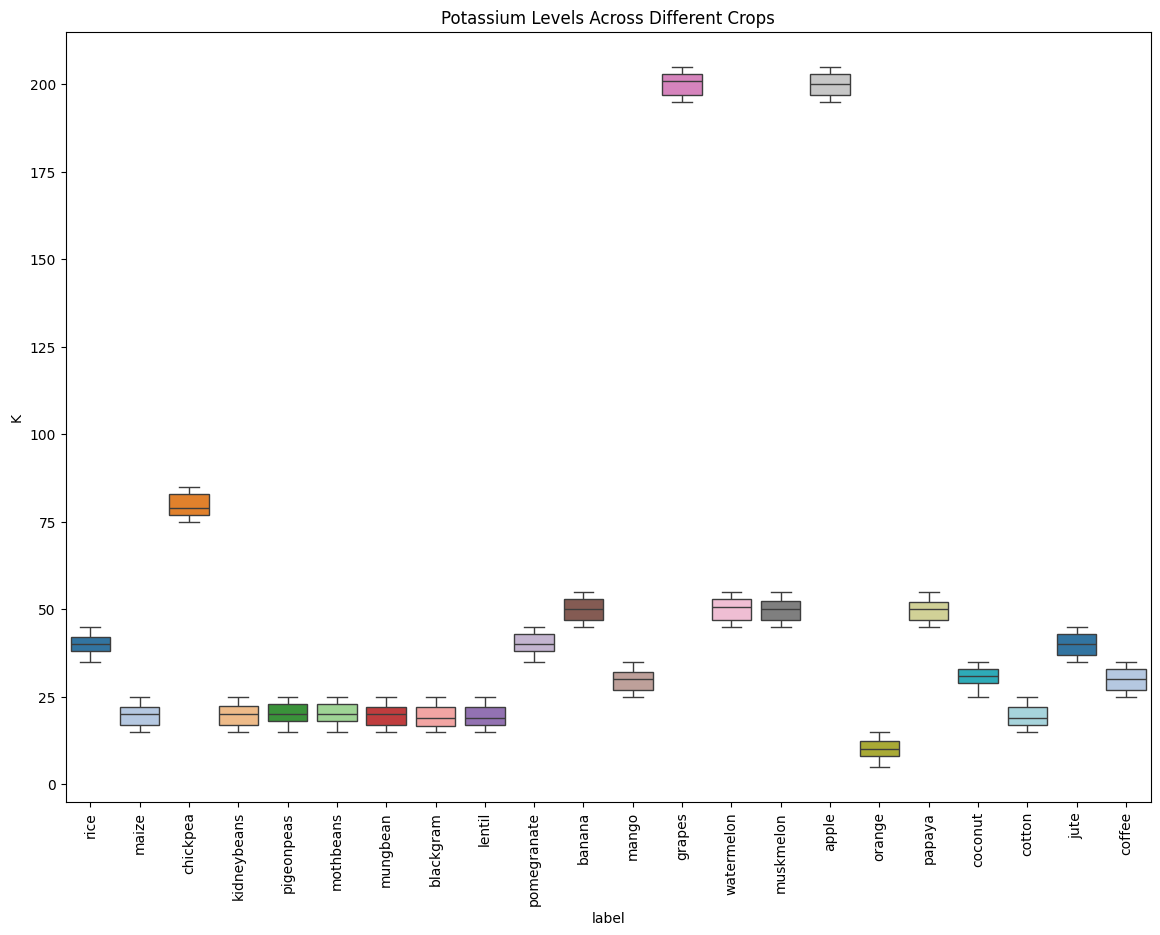

/tmp/ipython-input-2810592587.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=crop, x='label', y='temperature', palette='tab20')


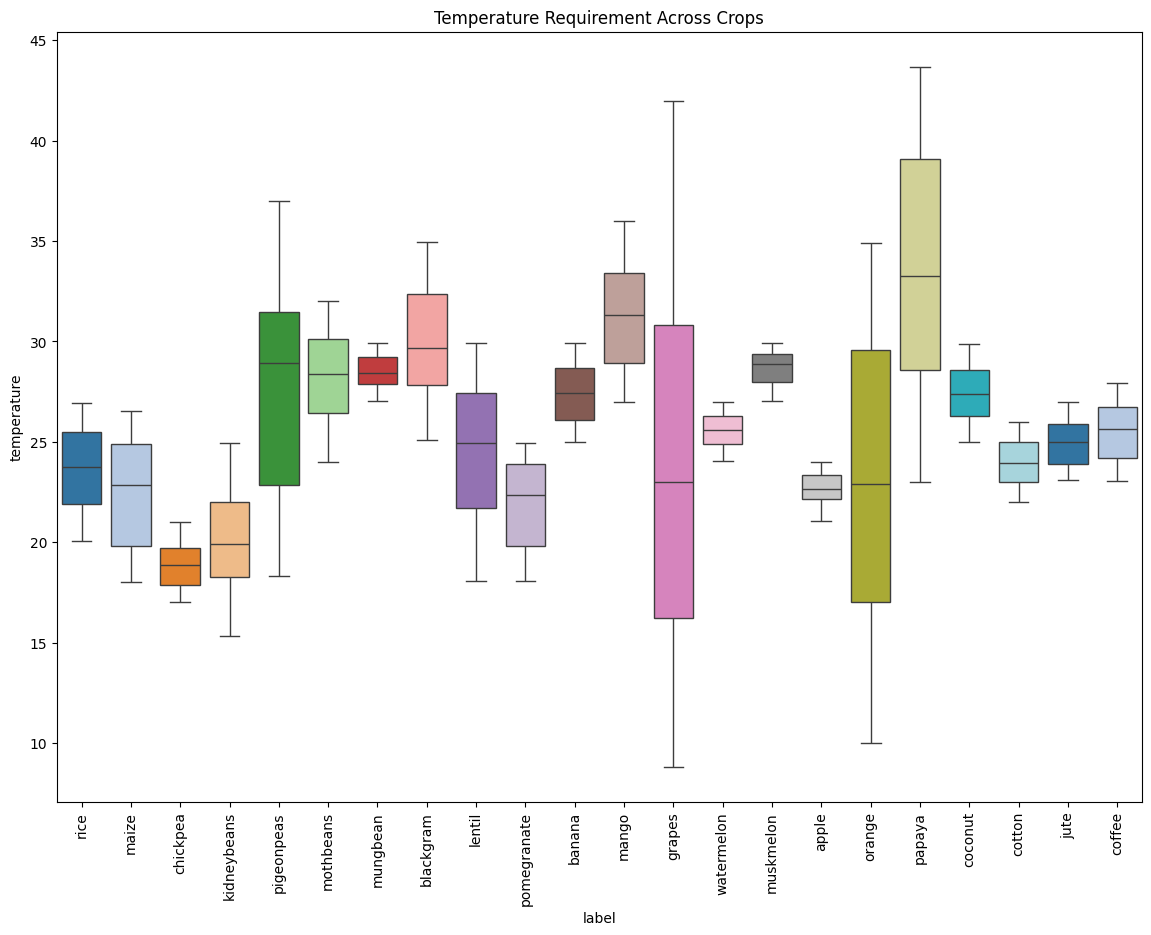

/tmp/ipython-input-2810592587.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=crop, x='label', y='humidity', palette='tab20')


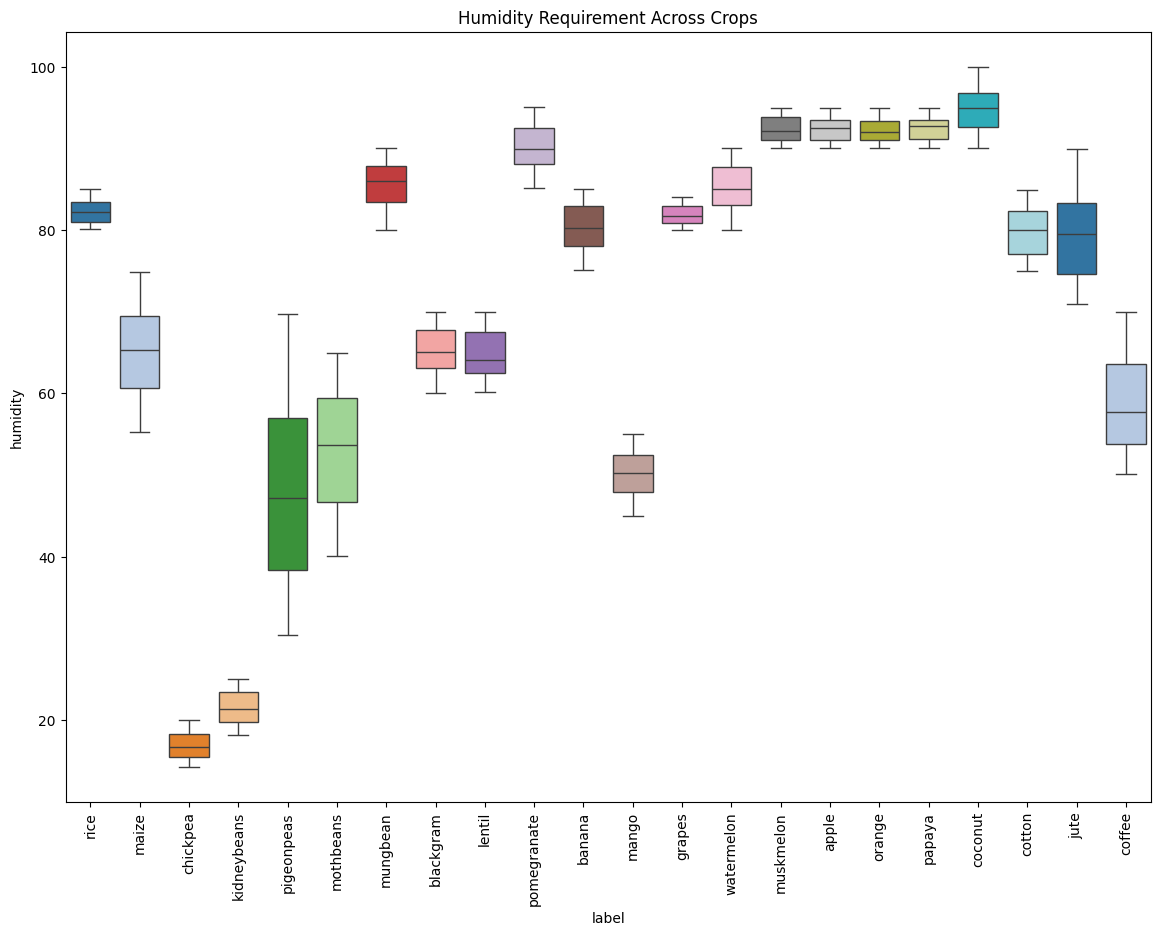

/tmp/ipython-input-2810592587.py:48: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=crop, x='label', y='ph', palette='tab20')


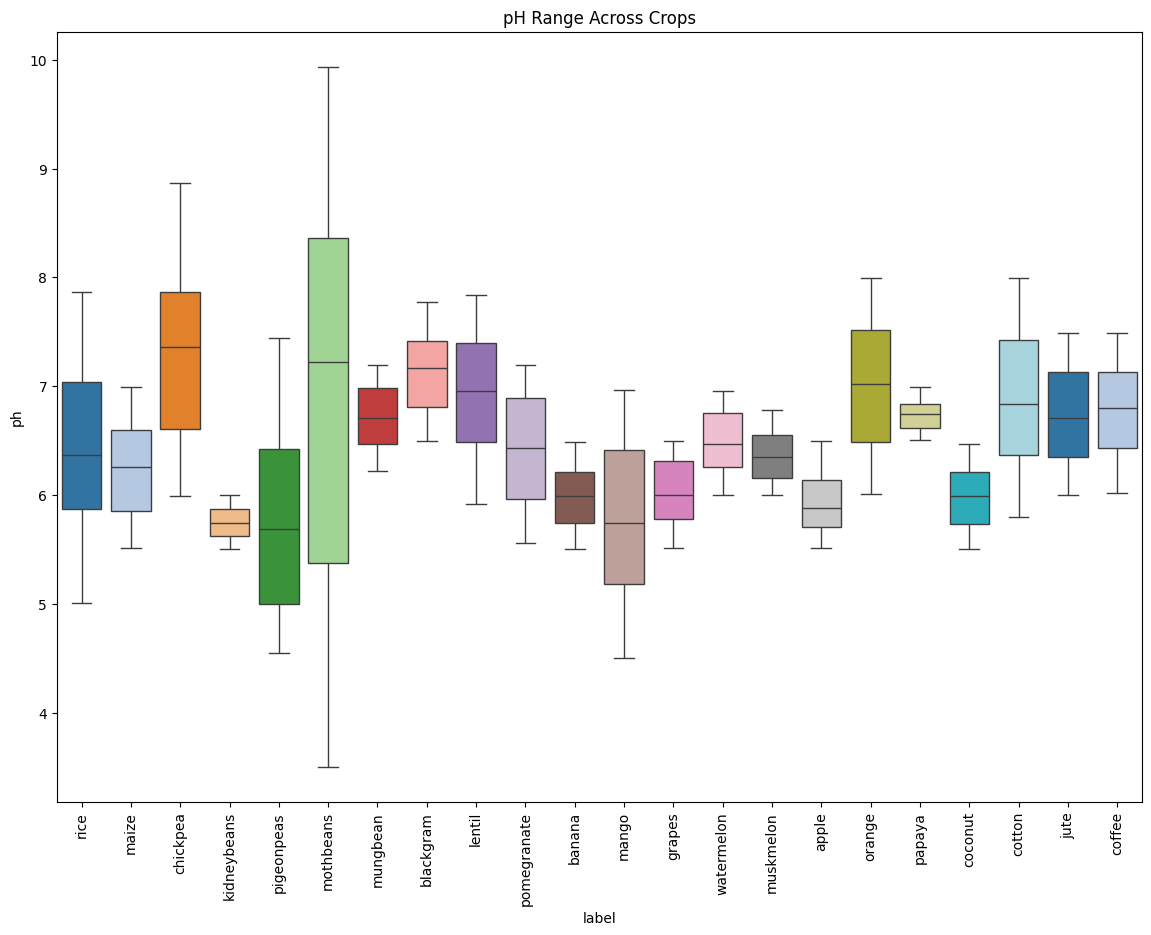

/tmp/ipython-input-2810592587.py:54: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=crop, x='label', y='rainfall', palette='tab20')


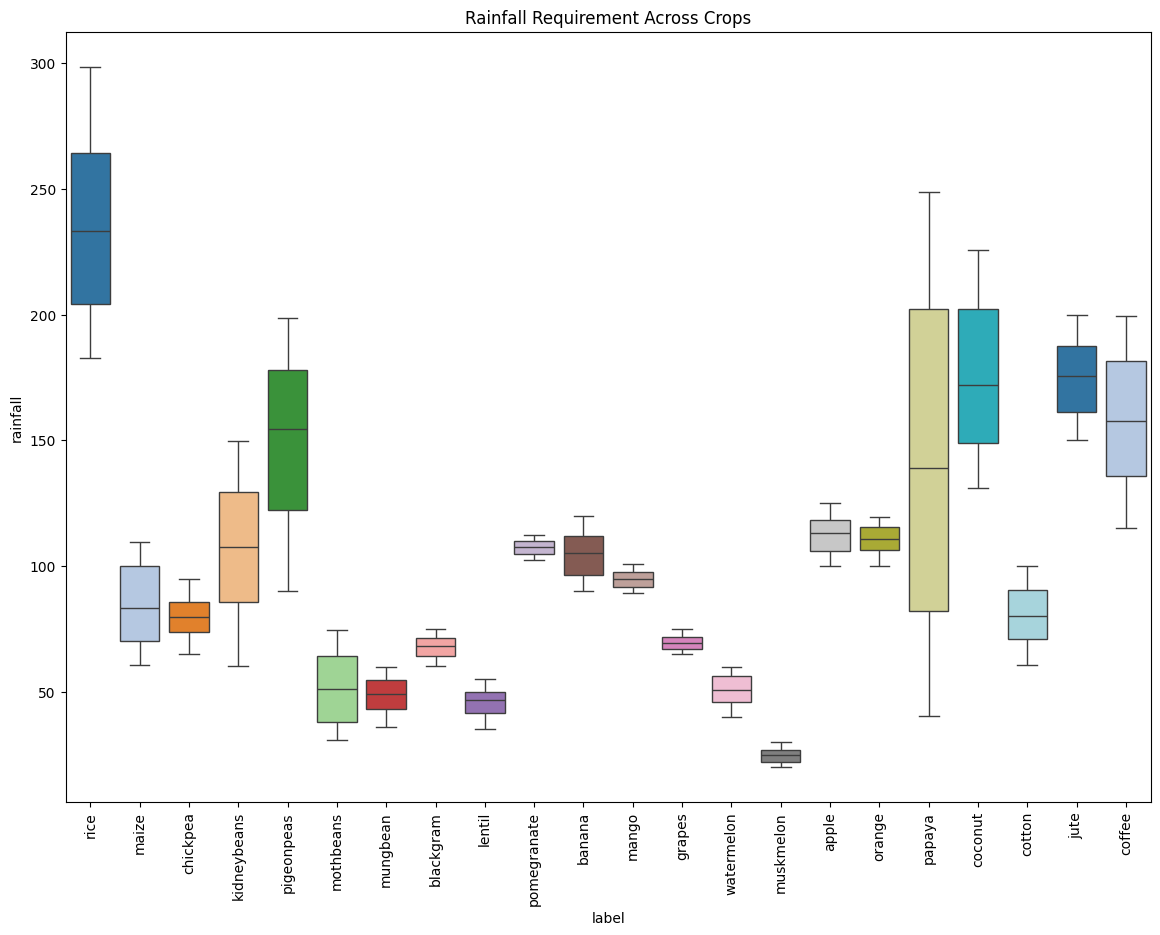

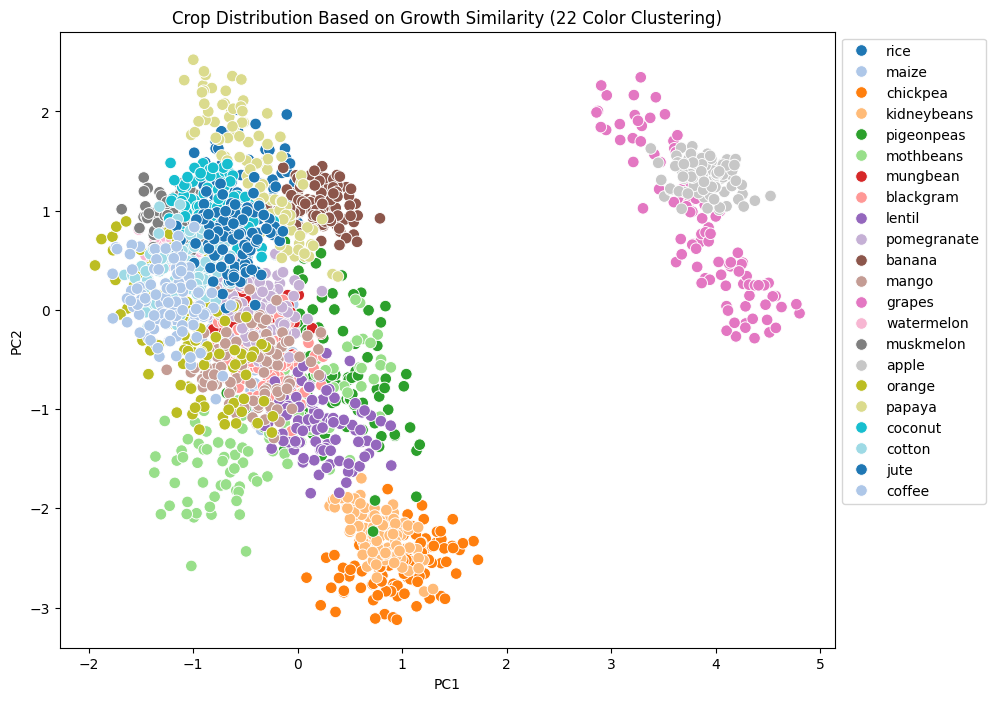


Crop-wise Mean Nutritional and Climate Requirements:
                  N       P       K  temperature   humidity        ph  \
label                                                                   
apple         20.80  134.22  199.89    22.630942  92.333383  5.929663   
banana       100.23   82.01   50.05    27.376798  80.358123  5.983893   
blackgram     40.02   67.47   19.24    29.973340  65.118426  7.133952   
chickpea      40.09   67.79   79.92    18.872847  16.860439  7.336957   
coconut       21.98   16.93   30.59    27.409892  94.844272  5.976562   
coffee       101.20   28.74   29.94    25.540477  58.869846  6.790308   
cotton       117.77   46.24   19.56    23.988958  79.843474  6.912675   
grapes        23.18  132.53  200.11    23.849575  81.875228  6.025937   
jute          78.40   46.86   39.99    24.958376  79.639864  6.732778   
kidneybeans   20.75   67.54   20.05    20.115085  21.605357  5.749411   
lentil        18.77   68.36   19.41    24.509052  64.804785  6.927932 

In [ ]:
# ===============================
# EDA FOR CROPS (22 Labels)
# ===============================

import seaborn as sns
import matplotlib.pyplot as plt

# 1. Crop Count Distribution (22 Categories - 22 Colors)
plt.figure(figsize=(10,8))
sns.countplot(y=crop['label'], palette='tab20', order=crop['label'].value_counts().index)
plt.title('Crop Frequency Distribution (22 Crop Types)')
plt.xlabel('Count')
plt.ylabel('Crop Type')
plt.show()

# 2. Boxplots of all features grouped by crop type
plt.figure(figsize=(14,10))
sns.boxplot(data=crop, x='label', y='N', palette='tab20')
plt.xticks(rotation=90)
plt.title('Nitrogen Levels Across Different Crops')
plt.show()

plt.figure(figsize=(14,10))
sns.boxplot(data=crop, x='label', y='P', palette='tab20')
plt.xticks(rotation=90)
plt.title('Phosphorus Levels Across Different Crops')
plt.show()

plt.figure(figsize=(14,10))
sns.boxplot(data=crop, x='label', y='K', palette='tab20')
plt.xticks(rotation=90)
plt.title('Potassium Levels Across Different Crops')
plt.show()

plt.figure(figsize=(14,10))
sns.boxplot(data=crop, x='label', y='temperature', palette='tab20')
plt.xticks(rotation=90)
plt.title('Temperature Requirement Across Crops')
plt.show()

plt.figure(figsize=(14,10))
sns.boxplot(data=crop, x='label', y='humidity', palette='tab20')
plt.xticks(rotation=90)
plt.title('Humidity Requirement Across Crops')
plt.show()

plt.figure(figsize=(14,10))
sns.boxplot(data=crop, x='label', y='ph', palette='tab20')
plt.xticks(rotation=90)
plt.title('pH Range Across Crops')
plt.show()

plt.figure(figsize=(14,10))
sns.boxplot(data=crop, x='label', y='rainfall', palette='tab20')
plt.xticks(rotation=90)
plt.title('Rainfall Requirement Across Crops')
plt.show()

# ===============================
# CLUSTERING BY CROP CATEGORY WITH 22 COLORS
# ===============================

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

num_cols = ['N','P','K','temperature','humidity','ph','rainfall']

# Scaling
scaler = StandardScaler()
scaled_data = scaler.fit_transform(crop[num_cols])

# Clustering (k chosen from elbow plot)
kmeans = KMeans(n_clusters=22, random_state=42)
crop['Crop_Cluster'] = kmeans.fit_predict(scaled_data)

# PCA for 22-color visualization
pca = PCA(n_components=2)
pca_vals = pca.fit_transform(scaled_data)
crop['PC1'], crop['PC2'] = pca_vals[:,0], pca_vals[:,1]

# Scatter plot (22 different colors for 22 crops)
plt.figure(figsize=(10,8))
sns.scatterplot(data=crop, x='PC1', y='PC2', hue='label', palette='tab20', s=70)
plt.title("Crop Distribution Based on Growth Similarity (22 Color Clustering)")
plt.legend(bbox_to_anchor=(1,1))  # move legend aside to avoid clutter
plt.show()

# Mean nutrient values per crop
print("\nCrop-wise Mean Nutritional and Climate Requirements:")
print(crop.groupby('label')[num_cols].mean())


# Correlation Matrix Visualization

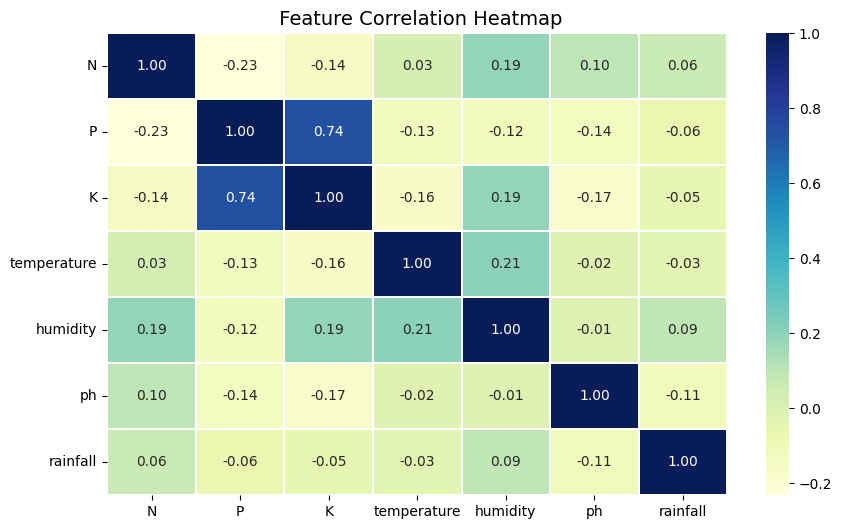

In [ ]:
plt.figure(figsize=(10,6))
corr = crop.drop('label', axis=1).corr()
sns.heatmap(corr, annot=True, cmap='YlGnBu', linewidths=0.3, fmt=".2f")
plt.title(" Feature Correlation Heatmap", fontsize=14)
plt.show()

# Split Data into Train and Test

In [ ]:
X = crop.drop('label', axis=1)
y = crop['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(" Data Split Completed!")
print("Training Size:", X_train.shape)
print("Testing Size:", X_test.shape)

 Data Split Completed!
Training Size: (1760, 7)
Testing Size: (440, 7)


# Feature Scaling

In [ ]:
# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#Train Initial RandomForest Model

In [ ]:
#Initial Model Training
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print(" Initial Model Accuracy:", accuracy_score(y_test, y_pred))

 Initial Model Accuracy: 0.9954545454545455


# Hyperparameter Tuning using GridSearchCV

In [ ]:

param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    n_jobs=-1,
    verbose=2,
    scoring='accuracy'
)

grid_search.fit(X_train, y_train)

print("\n Best Parameters Found:")
print(grid_search.best_params_)


Fitting 5 folds for each of 216 candidates, totalling 1080 fits

 Best Parameters Found:
{'bootstrap': True, 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}


# Evaluate Final Model

In [ ]:
best_rf = grid_search.best_estimator_

train_pred = best_rf.predict(X_train)
test_pred = best_rf.predict(X_test)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)
cv_scores = cross_val_score(best_rf, X, y, cv=5)
cv_mean, cv_std = cv_scores.mean(), cv_scores.std()

print("\n MODEL PERFORMANCE SUMMARY")
print(f" Training Accuracy: {train_acc:.4f}")
print(f" Testing Accuracy:  {test_acc:.4f}")
print(f" CV Accuracy (mean): {cv_mean:.4f}")
print(f" CV Std Dev: {cv_std:.4f}")


 MODEL PERFORMANCE SUMMARY
 Training Accuracy: 0.9966
 Testing Accuracy:  0.9955
 CV Accuracy (mean): 0.9927
 CV Std Dev: 0.0039


# Accuracy Comparison Chart

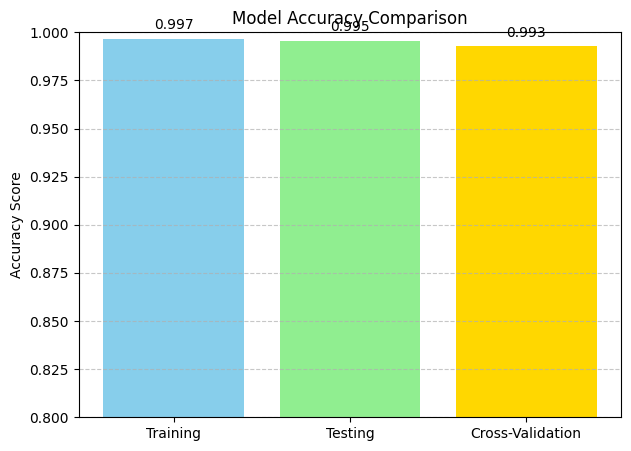

In [ ]:
plt.figure(figsize=(7,5))
bars = plt.bar(
    ["Training", "Testing", "Cross-Validation"],
    [train_acc, test_acc, cv_mean],
    color=["skyblue", "lightgreen", "gold"]
)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy Score")
plt.ylim(0.8, 1.0)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, yval+0.005, f"{yval:.3f}", ha='center')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Cross-Validation Trend Chart

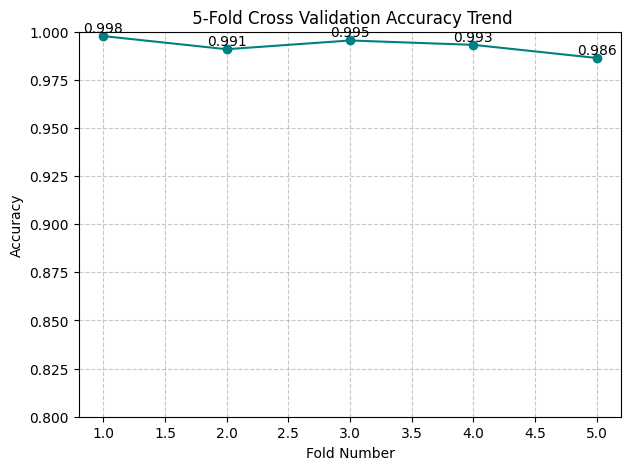

In [ ]:
plt.figure(figsize=(7,5))
plt.plot(range(1, 6), cv_scores, marker='o', linestyle='-', color='teal')
plt.title(" 5-Fold Cross Validation Accuracy Trend")
plt.xlabel("Fold Number")
plt.ylabel("Accuracy")
plt.ylim(0.8, 1.0)
for i, score in enumerate(cv_scores):
    plt.text(i+1, score+0.002, f"{score:.3f}", ha='center')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()


# Classification Report & Confusion Matrix


 Classification Report:

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        20
      banana       1.00      1.00      1.00        20
   blackgram       1.00      0.95      0.97        20
    chickpea       1.00      1.00      1.00        20
     coconut       1.00      1.00      1.00        20
      coffee       1.00      1.00      1.00        20
      cotton       1.00      1.00      1.00        20
      grapes       1.00      1.00      1.00        20
        jute       0.95      1.00      0.98        20
 kidneybeans       1.00      1.00      1.00        20
      lentil       1.00      1.00      1.00        20
       maize       0.95      1.00      0.98        20
       mango       1.00      1.00      1.00        20
   mothbeans       1.00      1.00      1.00        20
    mungbean       1.00      1.00      1.00        20
   muskmelon       1.00      1.00      1.00        20
      orange       1.00      1.00      1.00        20
 

<Figure size 1000x1000 with 0 Axes>

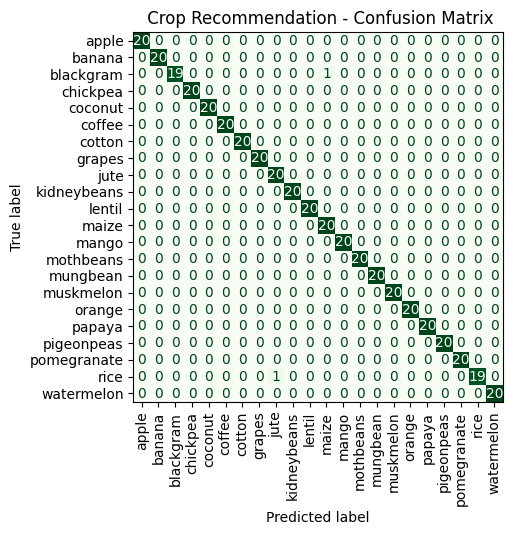

In [ ]:
print("\n Classification Report:\n")
print(classification_report(y_test, test_pred))

cm = confusion_matrix(y_test, test_pred, labels=best_rf.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_rf.classes_)

plt.figure(figsize=(10,10))
disp.plot(cmap='Greens', xticks_rotation=90, colorbar=False)
plt.title(" Crop Recommendation - Confusion Matrix")
plt.show()

# Feature Importance Plot

/tmp/ipython-input-4125103059.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importance.index, y=importance.values, palette='Greens_r')


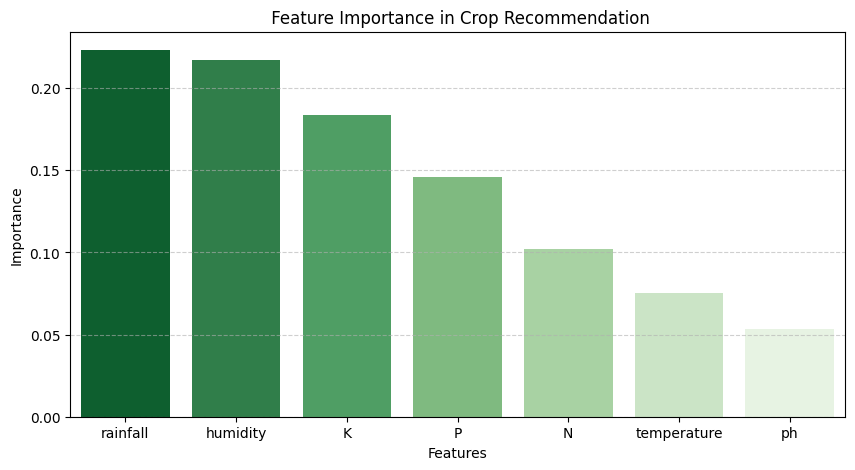


 Feature Importance Scores:
 rainfall       0.223133
humidity       0.216879
K              0.183446
P              0.145579
N              0.101962
temperature    0.075522
ph             0.053479
dtype: float64


In [ ]:
importance = pd.Series(best_rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=importance.index, y=importance.values, palette='Greens_r')
plt.title(" Feature Importance in Crop Recommendation")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

print("\n Feature Importance Scores:\n", importance)

# Test a Sample Prediction

In [ ]:
# Sample Prediction
sample = [[90, 42, 43, 20.87, 82.00, 6.5, 202.93]]
sample_scaled = scaler.transform(sample)
predicted_crop = best_rf.predict(sample_scaled)
print("\n Recommended Crop for Given Input:", predicted_crop[0])


 Recommended Crop for Given Input: rice


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# Save Model & Scaler

In [ ]:

joblib.dump(best_rf, 'best_crop_model.pkl')
joblib.dump(scaler, 'crop_scaler.pkl')
print("\n Model and Scaler saved successfully!")


 Model and Scaler saved successfully!
